In [1]:
here::i_am("snakemake/01_create_arrow.R")
source(here::here("settings.R"))
source(here::here("load_archr.R"))
options(repr.plot.width=15, repr.plot.height=5)

# I/O
io$output.directory <- file.path(io$basedir,"ArchR")
setwd(io$output.directory)
io$outdir <- file.path(io$output.directory,"qc")
dir.create(file.path(io$outdir), showWarnings = FALSE)

#############################
## Update ArchR's metadata ##
#############################

# Create metadata
archR_metadata <- getCellColData(ArchRProject) %>%
  as.data.table(keep.rownames = T) %>% setnames("rn","cell") %>%
  .[,c("cell", "TSSEnrichment", "ReadsInTSS", "PromoterRatio", "NucleosomeRatio", "nFrags", "DoubletEnrichment")] %>%
   .[,sample:=strsplit(cell,"#") %>% map_chr(1)]

stages = data.frame('sample' = c('rabbit_BGRGP1', 'rabbit_BGRGP2', 'rabbit_BGRGP3', 'rabbit_BGRGP4', 'rabbit_BGRGP5', 'rabbit_BGRGP6', 'rabbit_BGRGP7', 'rabbit_BGRGP8'),
                    'stage' = c('GD7', 'GD8', 'GD8', 'GD9_ExE', 'GD9', 'GD9', 'GD9', 'GD9' ))

archR_metadata = merge(archR_metadata, stages, by='sample')


metadata.to.archR <- archR_metadata %>% 
  .[cell%in%rownames(ArchRProject)] %>% setkey(cell) %>% .[rownames(ArchRProject)] %>%
  as.data.frame() %>% tibble::column_to_rownames("cell")

stopifnot(all(metadata.to.archR$TSSEnrichment_atac == getCellColData(ArchRProject, "TSSEnrichment")[[1]]))

for (i in colnames(metadata.to.archR)) {
  ArchRProject <- addCellColData(
    ArchRProject,
    data = metadata.to.archR[[i]], 
    name = i,
    cells = rownames(metadata.to.archR),
    force = TRUE
  )
}

fwrite(archR_metadata, file.path(io$output.directory, 'metadata.txt.gz'), sep="\t", na="NA", quote=F)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-' 

In [2]:
######################
## Define arguments ##
######################
args = list()

args$min_nFrags = 15000
args$min_tss_score = 2.9
args$max_doubletEnrichment = 10

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



png 
  2

png 
  2

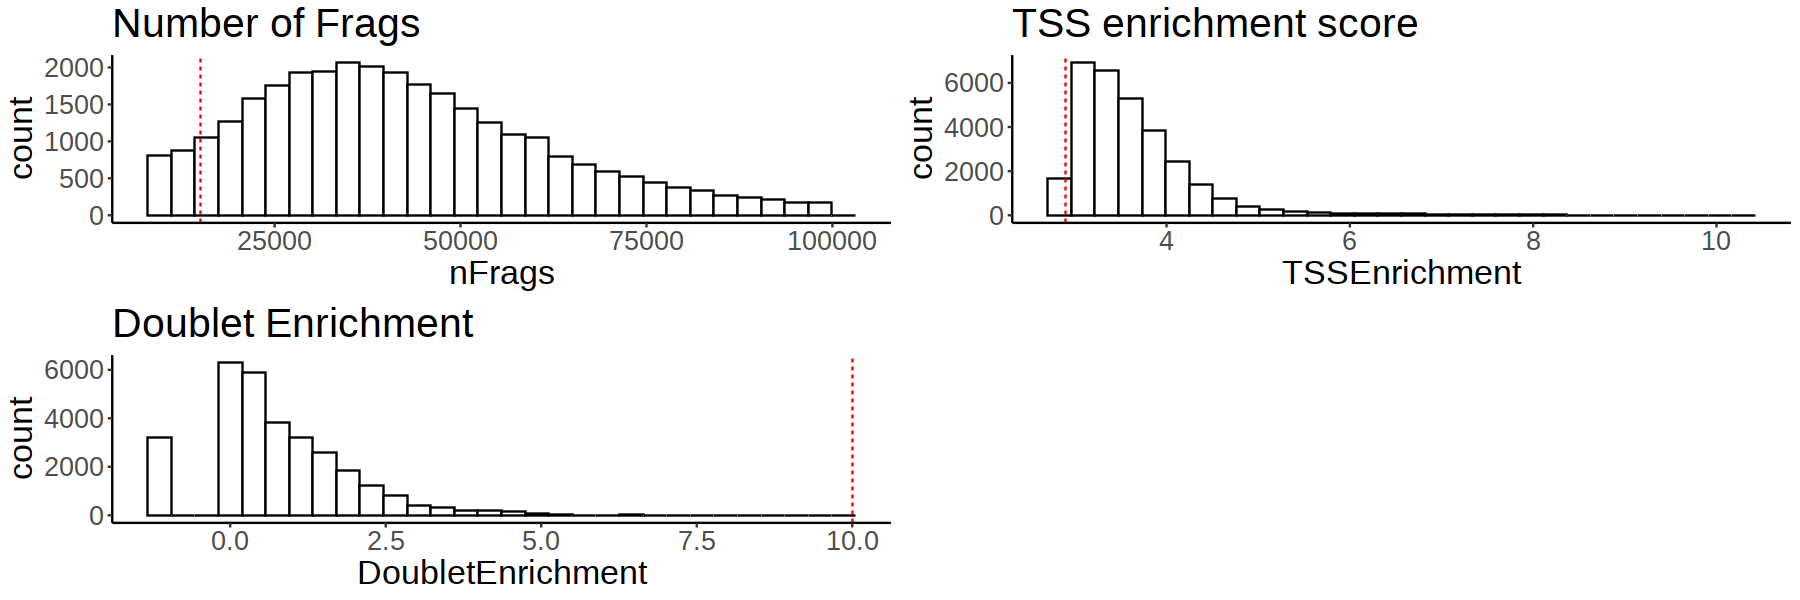

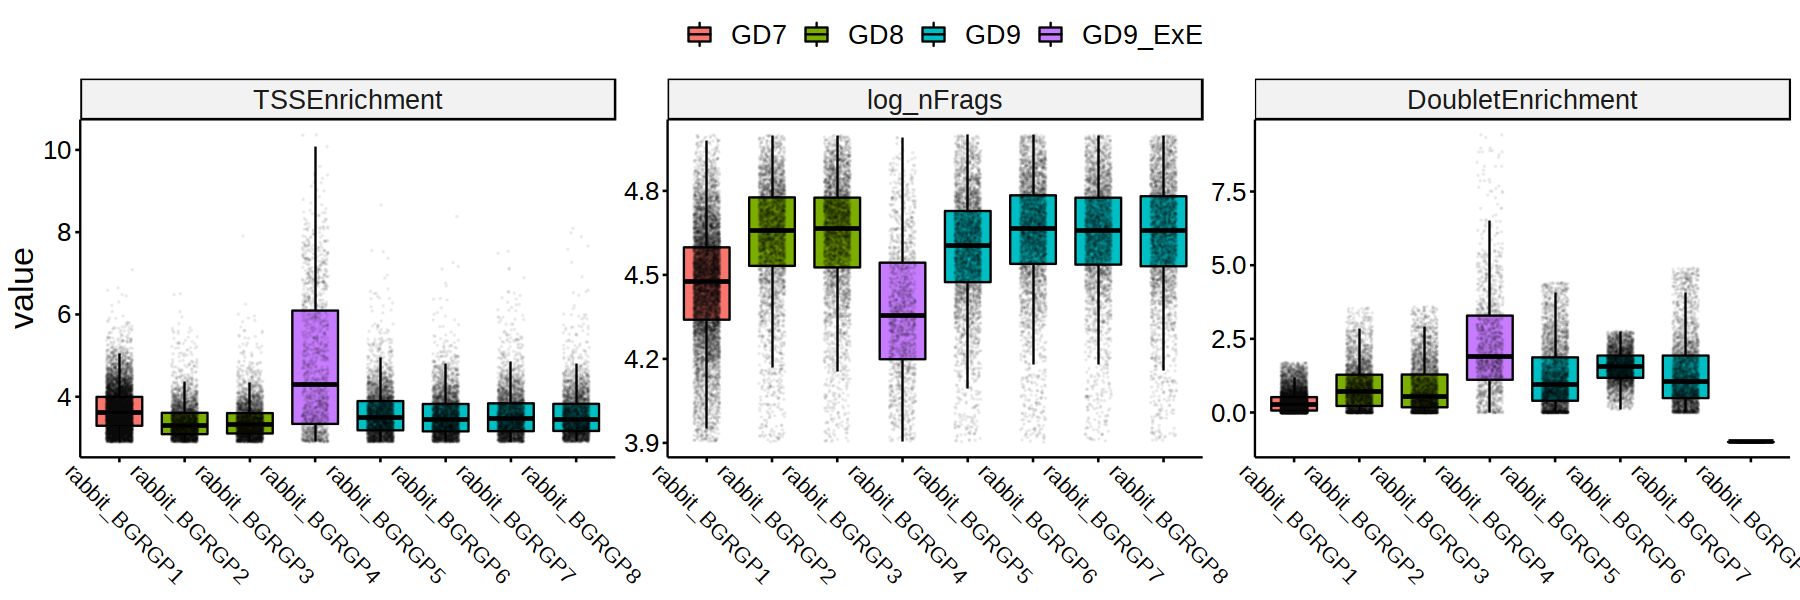

In [3]:
###########################################
## Plot summary statistics of QC metrics ##
###########################################

p1 = ggplot(archR_metadata, aes(nFrags)) + 
    geom_histogram(fill='white', color='black') + 
    ggtitle('Number of Frags') + 
    geom_vline(xintercept=args$min_nFrags, linetype='dashed', col='red') + 
    theme_classic() + theme(text=element_text(size=20))
p2 = ggplot(archR_metadata, aes(TSSEnrichment)) + 
    geom_histogram(fill='white', color='black') + 
    ggtitle('TSS enrichment score') + 
    geom_vline(xintercept=args$min_tss_score, linetype='dashed', col='red') + 
    theme_classic() + theme(text=element_text(size=20))
p3 = ggplot(archR_metadata, aes(DoubletEnrichment)) + 
    geom_histogram(fill='white', color='black') + 
    ggtitle('Doublet Enrichment') + 
    geom_vline(xintercept=args$max_doubletEnrichment, linetype='dashed', col='red') + 
    theme_classic() + theme(text=element_text(size=20))
p = ggarrange(p1, p2, p3)

pdf(sprintf("%s/qc_metrics_histogram.pdf",io$outdir), width=15, height=8)
print(p)
dev.off()
p

to.plot <- archR_metadata %>%
  .[,log_nFrags:=log10(nFrags)] %>%
  melt(id.vars=c("sample","cell","stage"), measure.vars=c("TSSEnrichment","log_nFrags", "DoubletEnrichment"))

# Boxplots
p <- ggboxplot(to.plot, x="sample", y="value", fill="stage", outlier.shape=NA) +
        geom_jitter(position=position_jitter(0.2), size = 0.001, alpha = 0.05) + 
        facet_wrap(~variable, scales="free_y") +
        theme(
        # legend.position = "none",
        legend.title = element_blank(),
        axis.text.x = element_text(colour="black",size=rel(0.65), angle=-45, vjust=0),  
        axis.text.y = element_text(colour="black",size=rel(0.75)),  
        axis.title.x = element_blank(),
        text=element_text(size=20)
        )

pdf(sprintf("%s/qc_metrics_boxplot.pdf",io$outdir), width=15, height=8)
print(p)
dev.off()
p

In [5]:
# % failing each QC criterium
paste0('pass TSSEnrichment: ',round(nrow(archR_metadata[archR_metadata$TSSEnrichment >= args$min_tss_score])/nrow(archR_metadata)*100,1), '%')
paste0('pass nFrags: ',round(nrow(archR_metadata[archR_metadata$nFrags>=args$min_nFrags])/nrow(archR_metadata)*100,1), '%')
paste0('pass DoubletEnrichment: ',round(nrow(archR_metadata[archR_metadata$DoubletEnrichment<=args$max_doubletEnrichment])/nrow(archR_metadata)*100,1), '%')



paste0('Cell # before QC: ', nrow(archR_metadata))
paste0('Cell # after QC: ', nrow(archR_metadata[archR_metadata$nFrags>=args$min_nFrags & archR_metadata$TSSEnrichment >= args$min_tss_score & archR_metadata$DoubletEnrichment<=args$max_doubletEnrichment,]))

[1] "pass TSSEnrichment: 100%"

[1] "pass nFrags: 93.8%"

[1] "pass DoubletEnrichment: 100%"

[1] "Cell # before QC: 30320"

[1] "Cell # after QC: 28439"

In [6]:
#############
## Call QC ##
#############

archR_metadata %>%
    .[,pass_atacQC:=TSSEnrichment>=args$min_tss_score & nFrags>=args$min_nFrags] %>%
    .[is.na(pass_atacQC),pass_atacQC:=FALSE]

fwrite(archR_metadata, file.path(io$output.directory, 'metadata_qc.txt.gz'), sep="\t", na="NA", quote=F)


######################### SAVE ###############################
#### FROM HERE ON WE ONLY WORK WITH CELLS THAT PASSED QC #####
##############################################################
archR_metadata_filt <- archR_metadata %>%
  .[pass_atacQC==TRUE] 
ArchRProject.filt <- ArchRProject[archR_metadata_filt$cell]

In [7]:
table(ArchRProject.filt@cellColData$sample)


rabbit_BGRGP1 rabbit_BGRGP2 rabbit_BGRGP3 rabbit_BGRGP4 rabbit_BGRGP5 
         7562          3234          3496          1133          3434 
rabbit_BGRGP6 rabbit_BGRGP7 rabbit_BGRGP8 
         3381          3130          3069 

In [8]:
saveArchRProject(ArchRProject.filt)

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
         

class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/ArchR/Project 
samples(8): rabbit_BGRGP1 rabbit_BGRGP2 ... rabbit_BGRGP7 rabbit_BGRGP8
sampleColData names(1): ArrowFiles
cellColData names(23): sample Sample ... cell Clusters_TileMatrix
numberOfCells(1): 28439
medianTSS(1): 3.467
medianFrags(1): 40984